<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia, centralizada en la plataforma SECOP II, representa uno de los pilares más críticos para la transparencia y la eficiencia del gasto del Estado. Sin embargo, la vasta cantidad de datos no estructurados y la complejidad de las variables involucradas dificultan la estimación precisa de costos, lo que puede derivar en ineficiencias presupuestales o falta de control sobre los recursos públicos.

Este proyecto surge como una solución tecnológica basada en Machine Learning para abordar el reto de la valoración de procesos contractuales. A través de un análisis comparativo entre modelos avanzados de Gradient Boosting (LightGBM y CatBoost) y técnicas de Procesamiento de Lenguaje Natural (NLP) como los Embeddings de texto, se busca construir un motor predictivo capaz de estimar el valor ajustado de un contrato a partir de su descripción técnica y características administrativas. Este modelo no solo optimiza la planeación financiera, sino que también sirve como una herramienta de auditoría para detectar desviaciones significativas en los precios de mercado.

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

*Procesamiento Semántico:* Implementar y evaluar dos estrategias de NLP para la columna "Objeto del Proceso": el uso de vectores densos (Embeddings) mediante Sentence Transformers y el procesamiento de texto nativo basado en diccionarios.

*Optimización del Modelado:* Ajustar modelos de regresión avanzados (CatBoost y LightGBM) bajo una escala logarítmica para mitigar el sesgo de los valores atípicos (outliers) comunes en la contratación estatal.

*Evaluación Comparativa:* Analizar el desempeño de los modelos mediante métricas financieras reales (MAE y RMSE) y de ajuste estadístico ($R^2$), determinando el margen de error promedio en pesos colombianos.

*Validación de Robustez:* Aplicar técnicas de Validación Cruzada (K-Fold Cross-Validation) sobre el modelo seleccionado para garantizar que la capacidad predictiva sea consistente y generalizable a diferentes sectores y departamentos del país.<br><br>


VARIABLES OBSERVADAS
<br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **Carga de librerias y datos:**

In [ ]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
import unicodedata
import re
from catboost import CatBoostRegressor
import warnings
import seaborn as sns
import pandas as pd
import catboost
import shap



df = pd.read_parquet('data/datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


## **Variables**

## **Visualizar el df**

In [2]:
# Mostrar  5 filas aleatorias
df.sample(5,random_state=25)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
98576,Territorial,706294725,MUNICIPIO DE PUERTO GAITAN,800079035,Meta,Puerto Gaitán,En ejecución,Contratación directa,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,2025-10-24T00:00:00.000,2025-10-24T00:00:00.000,2025-12-24T00:00:00.000,CO1.PCCNTR.8496546,1457-2025,5693333,DANIELA STEFFANY ROJAS ORTIZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1124818345
267521,Territorial,702730482,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,900958564,Distrito Capital de Bogotá,Bogotá,Modificado,Contratación régimen especial,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,Prestación de servicios,2025-10-02T00:00:00.000,2025-10-02T00:00:00.000,2026-01-09T00:00:00.000,CO1.PCCNTR.8401984,7218-2025,12585600,Milena Stefany Lopez Ramirez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018450196
286023,Territorial,701365033,MUNICIPIO DE ARMENIA QUINDIO,890000464,Quindío,Armenia,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-27T00:00:00.000,None,2026-01-15T00:00:00.000,CO1.PCCNTR.8635700,SETTA-CD-2025-4677,3750000,Oscar Posada Yepes,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,7529900
11020,Territorial,702727421,empresa social del estado región de salud soacha.,8000068503,Cundinamarca,Soacha,Borrador,Contratación régimen especial,NO DEFINIDO,Sin Descripcion,Prestación de servicios,None,None,None,CO1.PCCNTR.272027,CO1.PCCNTR.272027,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
219736,Territorial,702271321,(Secretaría Distrital de Integración Social),8999990619,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,Prestación de servicios,2025-11-18T00:00:00.000,None,2026-03-12T00:00:00.000,CO1.PCCNTR.8568972,11671-2025,15137640,DASSY MILENA GUTIERREZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,52288055


## **EDA**

In [3]:
# Obtener un resumen de la estructura del conjunto de datos:

print("\n-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,7,0
1,codigo_entidad_en_secop,object,5103,0
2,nombre_de_la_entidad,object,5239,0
3,nit_de_la_entidad,object,4200,0
4,departamento_entidad,object,38,0
5,municipio_entidad,object,1079,0
6,estado_del_proceso,object,19,0
7,modalidad_de_contrataci_n,object,31,0
8,objeto_a_contratar,object,165211,0
9,objeto_del_proceso,object,172952,1


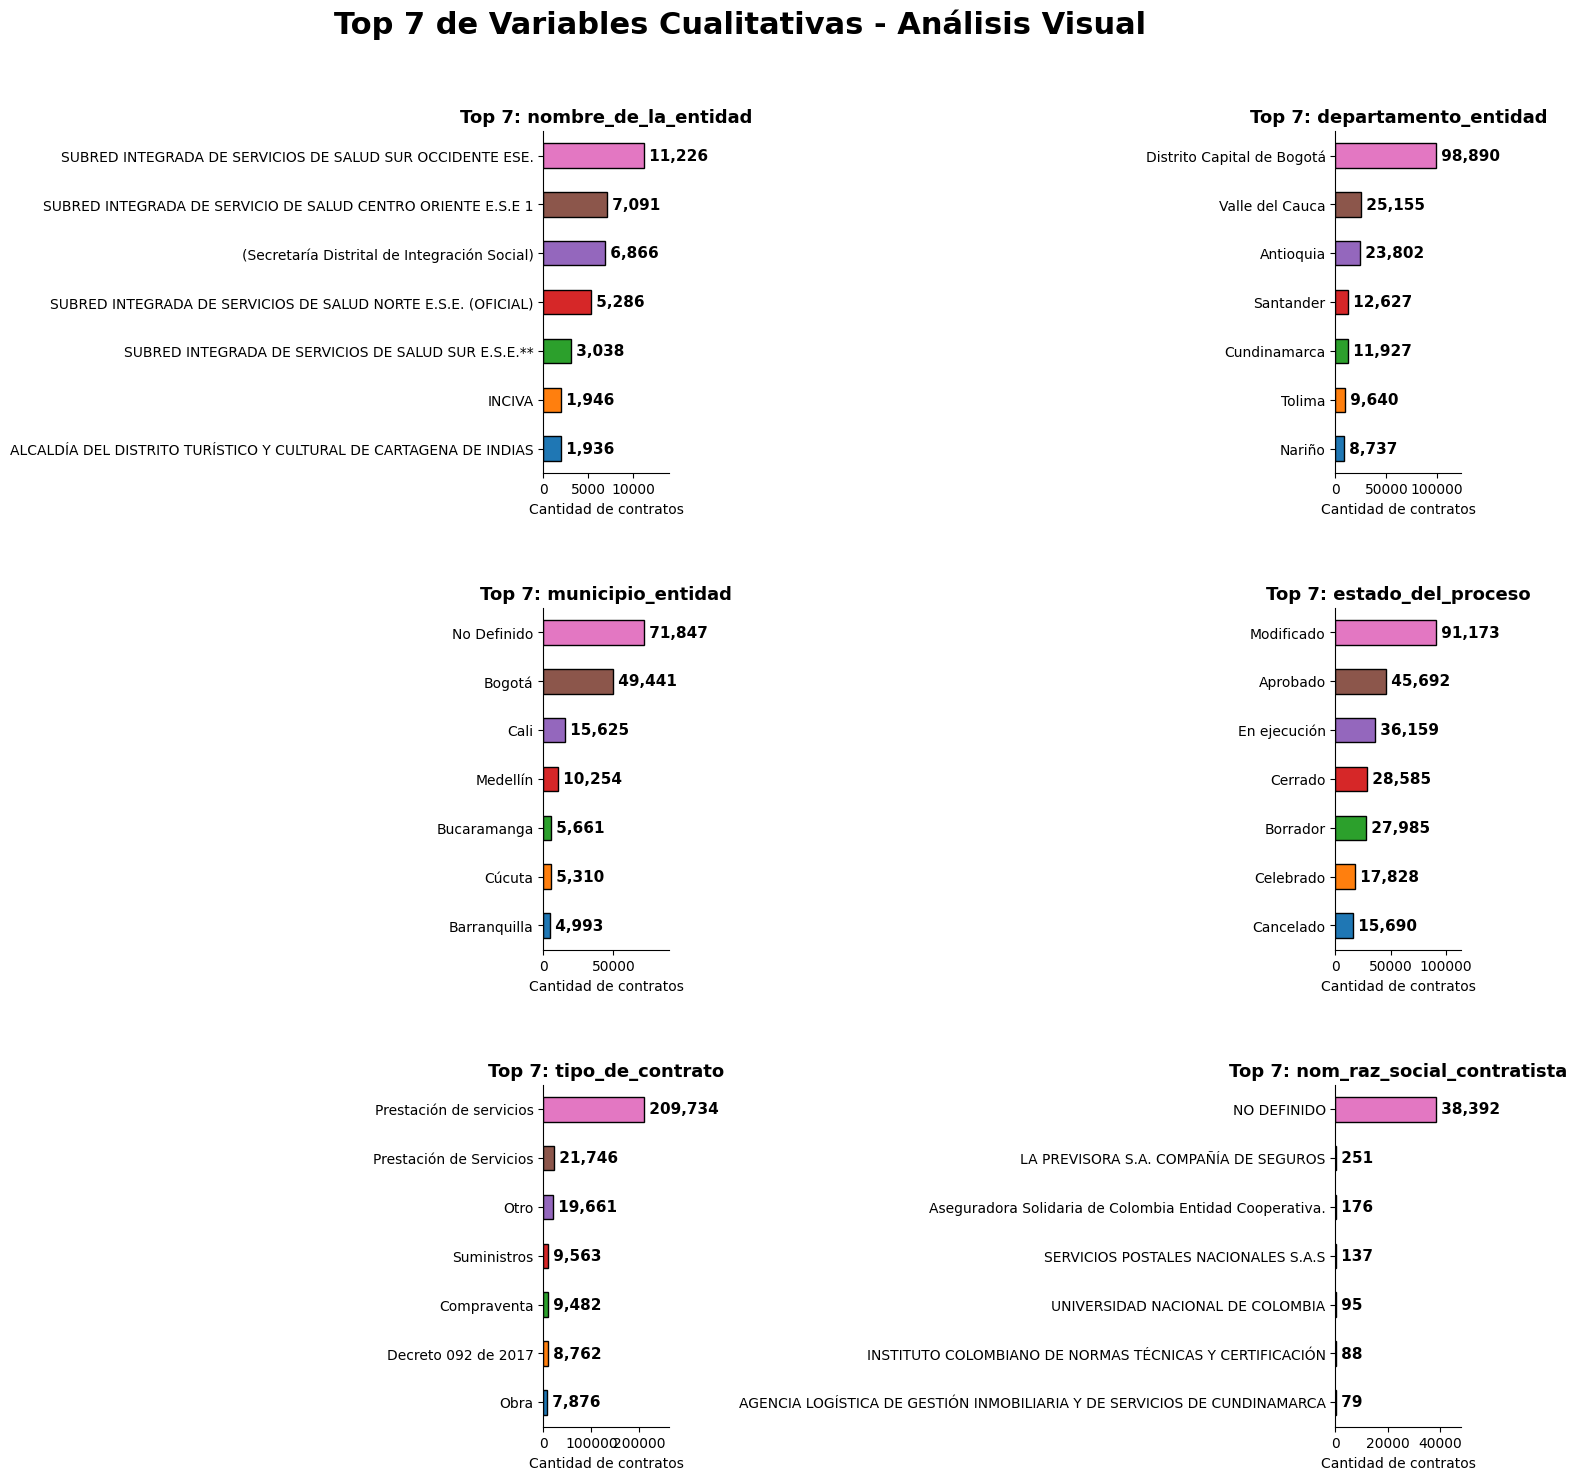

In [4]:
# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 7 ordenado
        datos = df[col].value_counts().head(7).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 7: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 7 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()

## **VALOR DEL CONTRATO**

Nuestra variable target es el valor del contrato el cual intentaremos predecir pero este tiene una escala que va desde miles de  pesos a billones es por eso que para el estudio, solo trabajaremos con los contratos de 1 millon a 200 millones que es donde mas se concentra la contratacion en Colombia.

## **Renombrar columnas**

In [5]:
# Quitar guion para los nombres de las columnas
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
    'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
    inplace=True)

## **DATA CLEANING**

## **Estados del proceso**

In [6]:
df["estado_del_proceso"].unique()

array(['Terminado sin Liquidar', 'Celebrado', 'En ejecución', 'Cerrado',
       'Aprobado', 'Modificado', 'Adjudicado', 'Convocado', 'Liquidado',
       'Terminado Anormalmente después de Convocado', 'cedido',
       'Borrador', 'enviado Proveedor', 'Cancelado', 'En aprobación',
       'Suspendido', 'terminado', 'Descartado',
       'Publicación para manifestaciones de interés'], dtype=object)

Para construir un modelo que prediga el valor de contratos en SECOP, NO todos los estados son igual de útiles. Algunos representan contratos reales y ejecutados, mientras que otros son etapas preliminares o procesos cancelados.

In [7]:
estados_validos = [
    'Celebrado',
    'Adjudicado',
    'En ejecución',
    'Liquidado',
    'Terminado',
    'Terminado sin Liquidar',
    'Modificado',
    'cerrado'
]

df = df[df['estado_del_proceso'].isin(estados_validos)]

In [8]:
df.shape[0]

147247

OBSERVACION: El dataset nos quedo con 147247 filas lo cual nos dice que exisitian  27958 contratos que a la fecha no se han aprobado y fueron eliminados para nuestro estudio, ademas tenemos  75269  filas que no tienen fecha de inicio de ejecucion (fecha_inicio_ejecucion), esto puede deberse que el contrato aun no se ha iniciado por lo que no debe tener fecha de terminacion (fecha_fin_ejecucion). Buscamos las filas que no tienen fechas en ninguna de las dos columnas (fantasmas).

Pasar variables de fecha a formato datetime


In [9]:
#numero de filas sin fecha de inicio de ejcucion
filas_sin_fecha_ejecucion=df['fecha_inicio_ejecucion'].isna().sum()
print(f"el numero de filas sin fecha de inicio de ejcucion es: {filas_sin_fecha_ejecucion}")

el numero de filas sin fecha de inicio de ejcucion es: 636


In [10]:
#aplicar fomato datetime

cols = ['fecha_de_firma_del_contrato', 'fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

df[cols] = df[cols].apply(
    lambda x: pd.to_datetime(x, errors='coerce').dt.normalize()
)

In [11]:
# 1. Obtenemos los índices de las filas con fecha de inicio nula
indices_sin_inicio = set(df[df['fecha_inicio_ejecucion'].isna()].index)

# 2. Obtenemos los índices de las filas con fecha de fin nula
indices_sin_fin = set(df[df['fecha_fin_ejecucion'].isna()].index)

# 3. Usamos la intersección (&) para saber cuáles no tienen NINGUNA de las dos
filas_sin_ambas = indices_sin_inicio & indices_sin_fin

print(f"Cantidad de contratos sin ambas fechas: {len(filas_sin_ambas)}")

df_fantasmas = df.loc[list(filas_sin_ambas)]


Cantidad de contratos sin ambas fechas: 636


Existen 636 contratos sin fechas de inicio y de ejecucion

In [12]:
#Elimina filas sin ambas fechas

df = df.drop(index=list(filas_sin_ambas)).copy()

In [13]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    0
fecha_inicio_ejecucion         0
fecha_fin_ejecucion            7
dtype: int64

aun tenemos 7 filas sin (fecha_inicio_ejecucion) por lo que las debemos borrar para poder obtener la duracion del del contrato en dias.

In [14]:

print(f"cantidad de filas del df {df.shape[0]}")

cantidad de filas del df 146611


## **Nueva variable duracion del contrato**

Creamos una variable que nos diga cuanto duro el contrato en dias

In [15]:
#Calculamos la duración en días
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

#Revisamos si hay anomalías obvias de inmediato
print("Estadísticas de la duración:")
print(df['duracion_dias'].describe())

#(Duración negativa)
negativos = (df['duracion_dias'] < 0).sum()
print(f"\n Contratos con fechas invertidas: {negativos}")


Estadísticas de la duración:
count    146604.000000
mean        169.662670
std         226.039747
min        -677.000000
25%          51.000000
50%         118.000000
75%         274.000000
max        8065.000000
Name: duracion_dias, dtype: float64

 Contratos con fechas invertidas: 95


existen 95 contratos con duraciones negativas esto puede deberse a errores de digitacion, para nuestro ejercicio eliminamos esas filas, estos serian contratos a revisar, pero para nuestro estudio estos contratos no aportarian informacion, por lo que los eliminamos del dataset.

In [16]:
# 1. Filtramos para trabajar solo con duraciones lógicas (mayores a 0)
df = df[df['duracion_dias'] > 0].copy()

In [17]:
filas_finales=len(df)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 146295

 filas iniciales dataset: 300000

 porcentaje eliminados: 51.23 %


Creamos una nueva variable llamada anio para extraer el año de la fecha de ejecucion del contrato


In [18]:
df['anio'] = df['fecha_inicio_ejecucion'].dt.year.astype('Int64')
df['mes'] = df['fecha_inicio_ejecucion'].dt.month.astype('Int64')


Eliminamos columnas innecesarias para modelar

In [19]:
#eliminar columnas que no usaremos en el modelado
columns_eliminar = ["nit_de_la_entidad",  
                    "numero_de_proceso",
                    "numero_del_contrato",
                    "objeto_a_contratar",
                    "nom_raz_social_contratista",
                    "documento_proveedor", 
                    "url_contrato",
                    "numero_del_contrato",
                    "fecha_de_firma_del_contrato",
                    "tipo_documento_proveedor",
                    "codigo_entidad_en_secop",
                    "fecha_inicio_ejecucion",
                    "fecha_fin_ejecucion",
                    "nombre_de_la_entidad"
                    ]

df= df.drop(columns=columns_eliminar)


analizamos la variable año (anio) para poder traer valor de los contratos a precio actual usando el ipc de cada año, (fuente DANE)

In [20]:
lista_anios = sorted(df['anio'].unique().tolist())
print(lista_anios)

[2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]


In [21]:
#eliminemos contratos con fecha de 2027
df = df[df['anio'] != 2027]

fuente de ipc pagina DANE

In [22]:
ipc_df = pd.DataFrame({
    'anio': [2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'ipc': [5.69, 7.67, 3.73, 2.44, 1.94, 3.66, 6.77, 5.75, 4.09, 3.18, 3.80, 1.61, 5.62, 13.12, 9.28, 5.20, 5.10, 5.56]
})

df = df.merge(ipc_df, on='anio', how='left')

In [23]:
#creamos columna con valor actual 

ipc_base = 5.66  #IPC a marzo de 2026

df['valor_ajustado'] = df['valor_contrato'] * (ipc_base / df['ipc'])

## **Análisis de la variable valor de contrato ajustado al IPC**

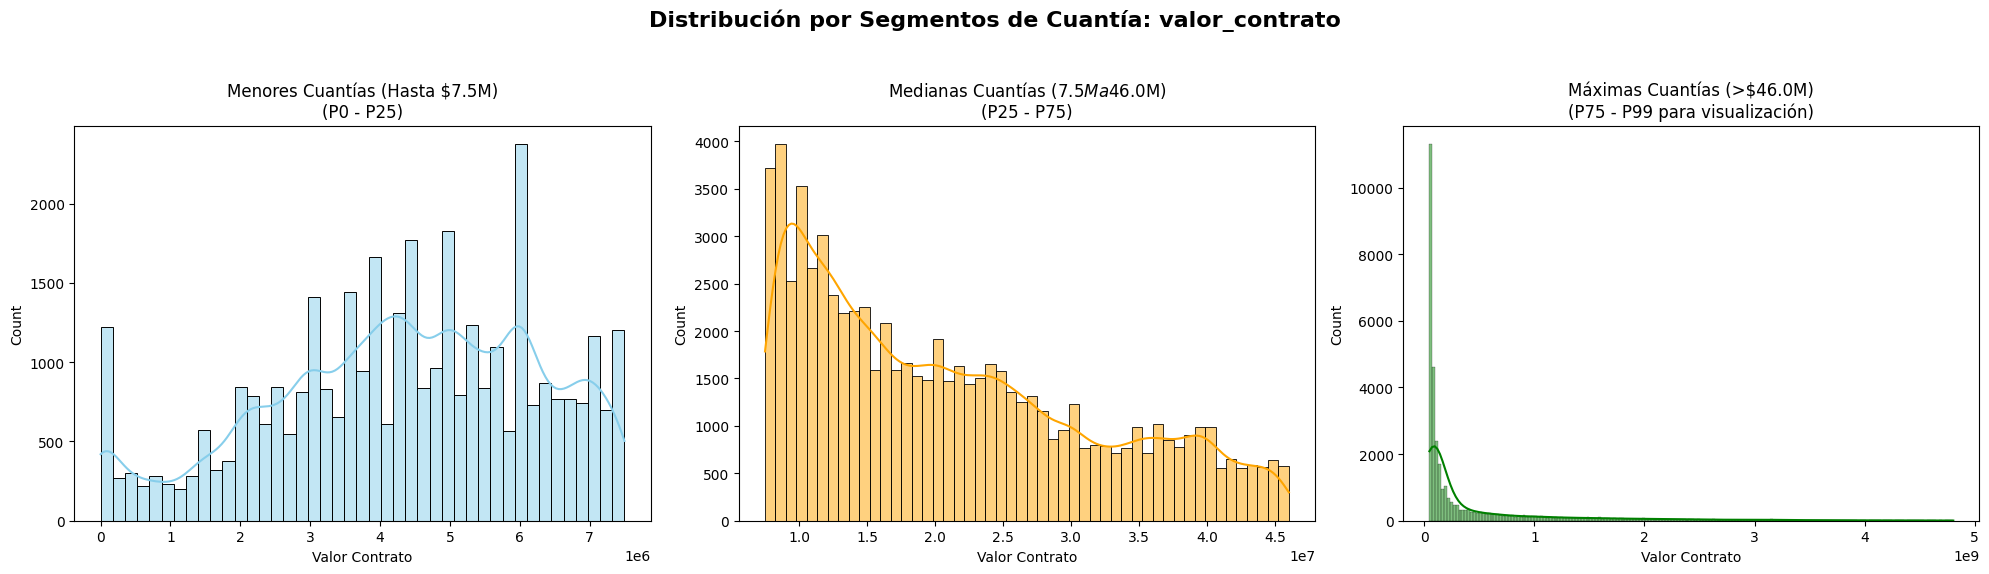

In [24]:
def graficar_segmentacion_cuantias(df, columna='valor_contrato'):
    """
    Genera tres histogramas basados en la segmentación por cuartiles (P25 y P75).
    Ayuda a visualizar la distribución de Menores, Medianas y Máximas cuantías.
    """
    # 1. Calcular los umbrales
    p25 = df[columna].quantile(0.25)
    p75 = df[columna].quantile(0.75)
    
    # 2. Configurar la figura (1 fila, 3 columnas)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Distribución por Segmentos de Cuantía: {columna}', fontsize=16, fontweight='bold')

    # --- SEGMENTO 1: Menores Cuantías ---
    data_menor = df[df[columna] <= p25]
    sns.histplot(data_menor[columna], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Menores Cuantías (Hasta ${p25/1e6:.1f}M)\n(P0 - P25)')
    axes[0].set_xlabel('Valor Contrato')

    # --- SEGMENTO 2: Medianas Cuantías ---
    data_mediana = df[(df[columna] > p25) & (df[columna] <= p75)]
    sns.histplot(data_mediana[columna], kde=True, ax=axes[1], color='orange')
    axes[1].set_title(f'Medianas Cuantías (${p25/1e6:.1f}M a ${p75/1e6:.1f}M)\n(P25 - P75)')
    axes[1].set_xlabel('Valor Contrato')

    # --- SEGMENTO 3: Máximas Cuantías (Con recorte al P99 para que sea visible) ---
    p99 = df[columna].quantile(0.99)
    data_maxima = df[(df[columna] > p75) & (df[columna] <= p99)]
    sns.histplot(data_maxima[columna], kde=True, ax=axes[2], color='green')
    axes[2].set_title(f'Máximas Cuantías (>${p75/1e6:.1f}M)\n(P75 - P99 para visualización)')
    axes[2].set_xlabel('Valor Contrato')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


graficar_segmentacion_cuantias(df)


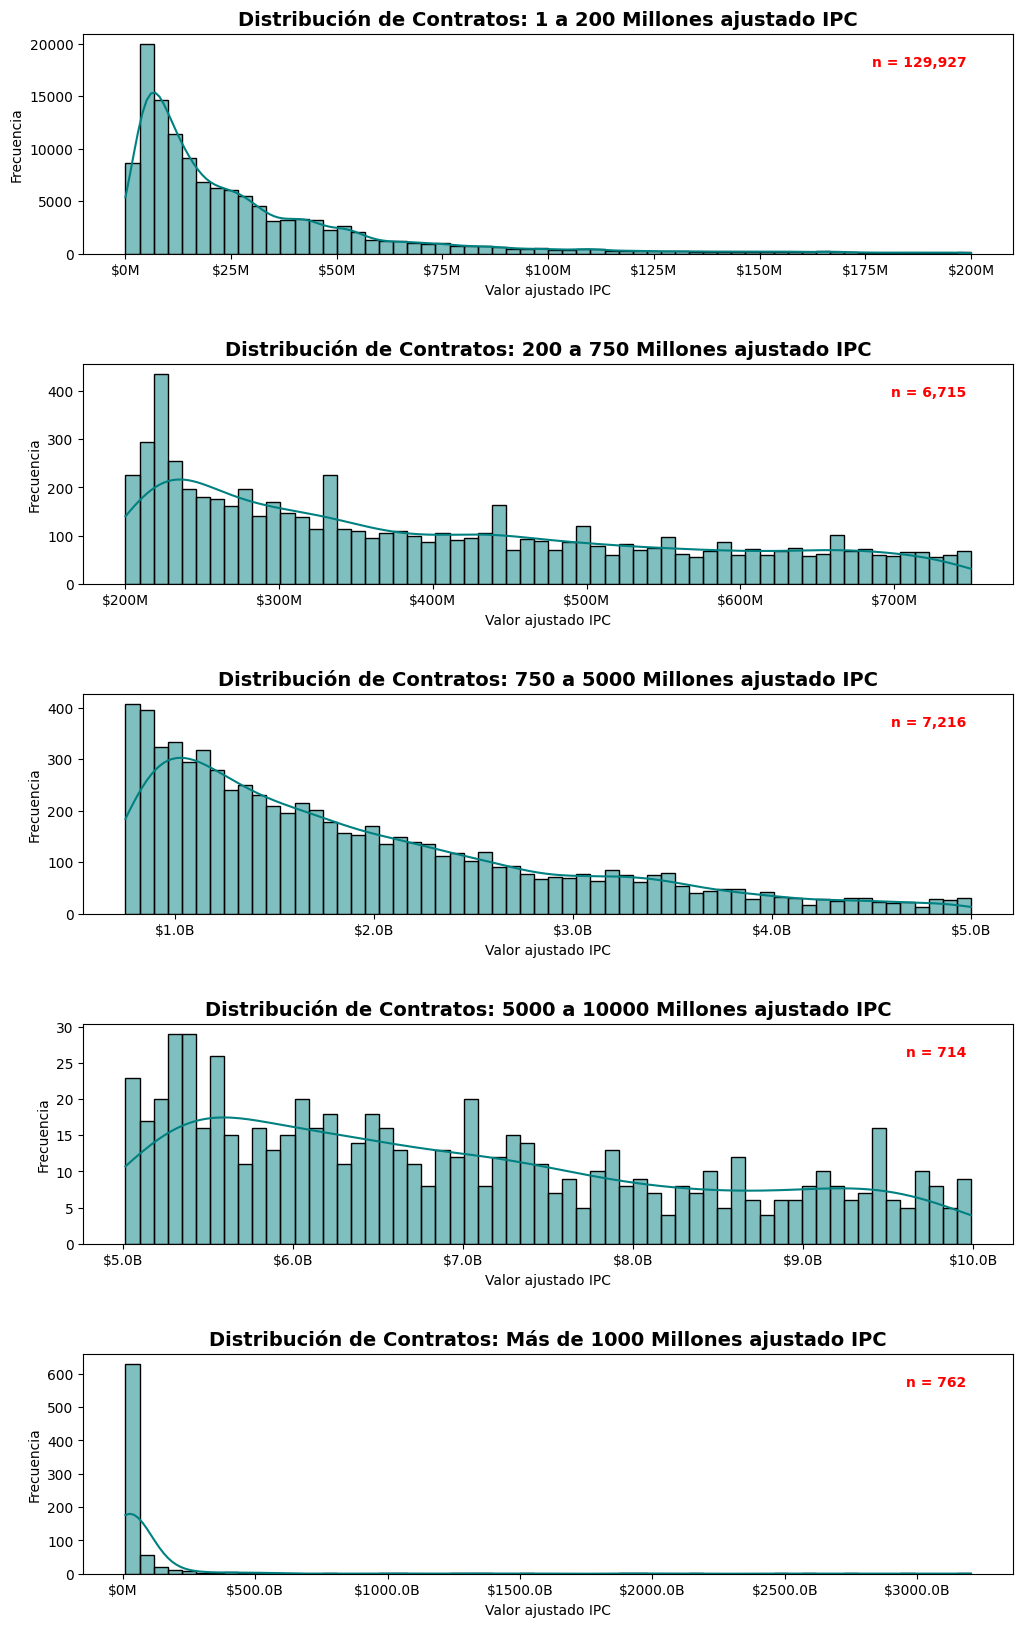

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Definir los rangos (limite_inferior, limite_superior, titulo)
rangos = [
    (1, 200e6, "1 a 200 Millones ajustado IPC"),
    (200e6, 750e6, "200 a 750 Millones ajustado IPC"),
    (750e6, 5000e6, "750 a 5000 Millones ajustado IPC"),
    (5000e6, 10000e6, "5000 a 10000 Millones ajustado IPC"),
    (10000e6, df['valor_contrato'].max(), "Más de 1000 Millones ajustado IPC")
]

# 2. Configurar la figura (5 filas, 1 columna)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20))
fig.subplots_adjust(hspace=0.5) # Espacio entre gráficas

# Función para dar formato de Millones/Billones al eje X
def format_money(x, pos):
    if x >= 1e9: return f'${x/1e9:.1f}B'
    return f'${x/1e6:.0f}M'

formatter = FuncFormatter(format_money)

# 3. Iterar y graficar
for i, (bajo, alto, titulo) in enumerate(rangos):
    # Filtrar datos para el rango actual
    data_filtrada = df[(df['valor_ajustado'] >= bajo) & (df['valor_ajustado'] <= alto)]
    
    # Graficar en el subeje correspondiente
    sns.histplot(data_filtrada['valor_ajustado'], bins=60, kde=True, ax=axes[i], color='teal')
    
    # Configurar títulos y etiquetas
    axes[i].set_title(f'Distribución de Contratos: {titulo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor ajustado IPC')
    axes[i].set_ylabel('Frecuencia')
    axes[i].xaxis.set_major_formatter(formatter)
    
    # Añadir un texto con la cantidad de contratos encontrados en ese rango
    axes[i].text(0.95, 0.85, f'n = {len(data_filtrada):,}', 
                 transform=axes[i].transAxes, ha='right', fontweight='bold', color='red')

plt.show()

In [26]:
df = df[
    (df['valor_ajustado'] >= 1_000_000) &
    
    (df['valor_ajustado'] <= 200_000_000)
].reset_index(drop=True)

**Análisis de la distribución de la variable valor_ajustado (valor contrato con IPC)**

*Selección de la distribución para el modelado*

Se opta por trabajar con la primera distribución correspondiente al rango de 1 a 200 millones del valor ajustado del contrato por IPC, debido a las siguientes razones estadísticas y metodológicas:
En primer lugar, esta distribución presenta el mayor tamaño muestral (n ≈ 129927) en comparación con los demás subconjuntos. Esto garantiza una mayor representatividad estadística, reduciendo la varianza de los estimadores y mejorando la capacidad de generalización del modelo.
En segundo lugar, aunque la variable exhibe una asimetría positiva (cola hacia la derecha), su comportamiento es más continuo y denso en comparación con los rangos superiores, donde se observa una mayor dispersión, presencia de valores extremos y menor densidad de observaciones. Estas características en los rangos altos pueden introducir inestabilidad en el entrenamiento y sesgos en modelos predictivos.
Adicionalmente, la primera distribución refleja de manera más fiel el comportamiento típico del fenómeno estudiado (contratación), evitando que el modelo esté dominado por outliers de alto valor, los cuales, aunque relevantes, son poco frecuentes.

*Transformación propuesta*

Dado que la distribución presenta sesgo positivo, se propone aplicar una transformación logarítmica de y= log(1+x)
Esta transformación se justifica porque:
Reduce la asimetría de la distribución, acercándola a una forma más normal.
Disminuye el impacto de valores extremos.
Mejora el desempeño de modelos que asumen cierta homocedasticidad o relaciones lineales.
Mantiene la interpretabilidad al trabajar con escalas relativas.



Para eliminar ruido solo tomamos lo que este por debajo del percentil 90 de los contratos de menos de 200 millones

In [27]:
df_filtrado=df

In [28]:
df_filtrado = df_filtrado.drop(columns=['ipc','valor_contrato'])

In [29]:
print(f"numero de filas resultantes {df_filtrado.shape[0]}")

numero de filas resultantes 128561


Limpieza de las filas eliminando tildes, espacios, urls, numeros con la funcion limpieza_total ya creada

In [30]:
from limpieza_texto import limpieza_total

# Definimos las columnas a ignorar
ignore = ['valor_ajustado','anio','duracion_dias','origen','fecha_inicio_ejecucion','fecha_fin_ejecucion','mes']
target_cols = [c for c in df_filtrado.columns if c not in ignore]

# Aplicamos la función 
df_filtrado[target_cols] = df_filtrado[target_cols].map(limpieza_total)


Filas eliminadas en total 

In [31]:
filas_finales=len(df_filtrado)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas finales: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas finales: 128561

 filas iniciales dataset: 300000

 porcentaje eliminados: 57.15 %


Tomamos una muestra para el modelo ya que introducir las 131694 mil filas tardaria demasiado en modelarse en la cpu

In [32]:
# Tomar una muestra del 50% del dataset
df_sample = df_filtrado.sample(frac=0.5, random_state=42).reset_index(drop=True)
df_sample.shape[0]


64280

In [33]:
df_sample.head() #Dataset para Catboost

,nivel_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_del_proceso,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado
0,nacional,antioquia,medellin,en ejecucion,contratacion directa,prestacion de servicios de apoyo a la gestion ...,prestacion de servicios,SECOPII,70.0,2025,10,9.311738e+06
1,territorial,cauca,popayan,modificado,contratacion directa,prestar servicios profesionales especializados...,prestacion de servicios,SECOPII,164.0,2025,7,2.672408e+07
2,territorial,magdalena,plato,en ejecucion,contratacion regimen especial,prestacion de servicios de auxiliar de enferme...,prestacion de servicios,SECOPII,5.0,2025,11,1.720196e+06
3,territorial,narino,pasto,modificado,contratacion directa,el contratista se compromete para con el munic...,prestacion de servicios,SECOPII,174.0,2025,7,1.065412e+07
4,nacional,distrito capital de bogota,bogota,en ejecucion,contratacion directa,prestar servicios de apoyo a la gestion en las...,prestacion de servicios,SECOPII,53.0,2025,11,4.981494e+06


In [34]:
# 1. Exportar el DataFrame a CSV para realizar embeddings del modelo lightbm en colab
df_sample.to_csv('data/df_clean_sample.csv', index=False, encoding='utf-8-sig')

print("Archivo exportado correctamente como 'df_clean_sample.csv'")

Archivo exportado correctamente como 'df_clean_sample.csv'


repositorio colab para generaR embeddings en el modelo LightGBM:

https://colab.research.google.com/drive/1-db7ZUO1I2zU9xwndSeRFKSbIuPi1ec2?usp=sharing

In [35]:
generar_diccionario(df_sample)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,4,0
1,departamento_entidad,object,35,0
2,municipio_entidad,object,960,0
3,estado_del_proceso,object,5,0
4,modalidad_de_contratacion,object,18,0
5,objeto_del_proceso,object,40690,0
6,tipo_de_contrato,object,25,0
7,origen,object,2,0
8,duracion_dias,float64,635,0
9,anio,Int64,16,0


llamamos el archivo con embeddings que se genero en collab.

In [36]:
df_embeddings = pd.read_parquet(
    'data/df_model_embeddings.parquet'
)


In [37]:
df_embeddings = df_embeddings.drop(columns=['municipio_entidad'])

In [38]:
df_embeddings.head(3)

,nivel_entidad,departamento_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_del_proceso,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,emb_64,emb_65,emb_66,emb_67,emb_68,emb_69,emb_70,emb_71,emb_72,emb_73,emb_74,emb_75,emb_76,emb_77,emb_78,emb_79,emb_80,emb_81,emb_82,emb_83,emb_84,emb_85,emb_86,emb_87,emb_88,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130,emb_131,emb_132,emb_133,emb_134,emb_135,emb_136,emb_137,emb_138,emb_139,emb_140,emb_141,emb_142,emb_143,emb_144,emb_145,emb_146,emb_147,emb_148,emb_149,emb_150,emb_151,emb_152,emb_153,emb_154,emb_155,emb_156,emb_157,emb_158,emb_159,emb_160,emb_161,emb_162,emb_163,emb_164,emb_165,emb_166,emb_167,emb_168,emb_169,emb_170,emb_171,emb_172,emb_173,emb_174,emb_175,emb_176,emb_177,emb_178,emb_179,emb_180,emb_181,emb_182,emb_183,emb_184,emb_185,emb_186,emb_187,emb_188,emb_189,emb_190,emb_191,emb_192,emb_193,emb_194,emb_195,emb_196,emb_197,emb_198,emb_199,emb_200,emb_201,emb_202,emb_203,emb_204,emb_205,emb_206,emb_207,emb_208,emb_209,emb_210,emb_211,emb_212,emb_213,emb_214,emb_215,emb_216,emb_217,emb_218,emb_219,emb_220,emb_221,emb_222,emb_223,emb_224,emb_225,emb_226,emb_227,emb_228,emb_229,emb_230,emb_231,emb_232,emb_233,emb_234,emb_235,emb_236,emb_237,emb_238,emb_239,emb_240,emb_241,emb_242,emb_243,emb_244,emb_245,emb_246,emb_247,emb_248,emb_249,emb_250,emb_251,emb_252,emb_253,emb_254,emb_255,emb_256,emb_257,emb_258,emb_259,emb_260,emb_261,emb_262,emb_263,emb_264,emb_265,emb_266,emb_267,emb_268,emb_269,emb_270,emb_271,emb_272,emb_273,emb_274,emb_275,emb_276,emb_277,emb_278,emb_279,emb_280,emb_281,emb_282,emb_283,emb_284,emb_285,emb_286,emb_287,emb_288,emb_289,emb_290,emb_291,emb_292,emb_293,emb_294,emb_295,emb_296,emb_297,emb_298,emb_299,emb_300,emb_301,emb_302,emb_303,emb_304,emb_305,emb_306,emb_307,emb_308,emb_309,emb_310,emb_311,emb_312,emb_313,emb_314,emb_315,emb_316,emb_317,emb_318,emb_319,emb_320,emb_321,emb_322,emb_323,emb_324,emb_325,emb_326,emb_327,emb_328,emb_329,emb_330,emb_331,emb_332,emb_333,emb_334,emb_335,emb_336,emb_337,emb_338,emb_339,emb_340,emb_341,emb_342,emb_343,emb_344,emb_345,emb_346,emb_347,emb_348,emb_349,emb_350,emb_351,emb_352,emb_353,emb_354,emb_355,emb_356,emb_357,emb_358,emb_359,emb_360,emb_361,emb_362,emb_363,emb_364,emb_365,emb_366,emb_367,emb_368,emb_369,emb_370,emb_371,emb_372,emb_373,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,nacional,antioquia,en ejecucion,contratacion directa,prestacion de servicios de apoyo a la gestion ...,prestacion de servicios,SECOPII,70.0,2025,10,9.311738e+06,-0.054703,-0.044093,-0.125565,0.016912,0.119840,0.045643,-0.045774,0.054993,-0.278865,0.01096,0.006246,0.141319,0.023269,-0.183808,0.031772,0.107151,0.009447,-0.041303,0.098857,0.189304,0.086348,-0.183271,-0.187438,-0.295517,0.175248,0.042161,0.027075,-0.005808,0.035532,-0.285127,0.108175,-0.151353,-0.260621,0.027457,0.179412,0.134330,0.085545,-0.087809,0.168137,0.066691,0.089458,-0.038745,-0.155491,-0.108100,-0.220679,-0.137934,-0.075271,-0.140384,-0.369023,-0.013622,0.036178,-0.185392,0.059115,-0.026384,0.089613,-0.067546,0.095808,0.072826,-0.079019,0.175819,0.024354,0.090532,-0.215979,-0.103260,-0.040421,0.197314,-0.118885,-0.002773,-0.239330,-0.230575,-0.013939,-0.163554,-0.360619,-0.151136,0.128410,

## Justificación Técnica: Función de Pérdida, Escalamiento y Modelos Utilizados

Para el entrenamiento de este proyecto se seleccionó la combinación de Transformación Logarítmica a la variable target (valor ajustado) que es el valor ajustado al IPC, la función de pérdida RMSE (Root Mean Squared Error), MAE (Mean Absolute Error) y  R² (Coeficiente de Determinación), utilizando los modelos CatBoost y LightGBM.
Para el modelo CatBoost se entrega la columna (`objeto_del_proceso`) el modelo no la interpreta directamente como un valor numérico, sino que aplica mecanismos internos de codificación para transformar el texto en información utilizable durante el entrenamiento.
para el modelo LightGBM se entregan las columnas de embeddings las cuales se crearon en COLAB y se cargan en el df_embeddings.

### Estabilización de la Varianza (Heterocedasticidad)

Los datos de contratación pública presentan una alta asimetría hacia la derecha, ya que existen numerosos contratos de montos pequeños y unos pocos contratos de valores extremadamente altos (outliers). Esta distribución genera problemas deh eterocedasticidad y dificulta el aprendizaje del modelo.
Por esta razón, se aplicó una transformación logarítmica sobre la variable objetivo (`valor_ajustado`). Esta técnica reduce el impacto de los valores extremos y permite estabilizar la varianza de los datos.

**Efecto:**
La transformación evita que los contratos multimillonarios dominen completamente el entrenamiento, permitiendo que el modelo aprenda patrones tanto en contratos pequeños como en contratos de alto valor.

---


### RMSE (Root Mean Squared Error)

El RMSE eleva el error al cuadrado antes de promediarlo, penalizando fuertemente las predicciones con grandes desviaciones. Esto obliga al modelo a ser más preciso en contratos donde el error económico puede ser significativo.
Adicionalmente, el RMSE es una función suave y derivable, lo que permite que los algoritmos de Gradient Boosting optimicen el error de manera más estable y eficiente mediante descenso de gradiente.

### MAE (Mean Absolute Error)

El MAE calcula el promedio absoluto de los errores entre el valor real y el valor predicho. Esta métrica permite interpretar de manera directa el error promedio del modelo en unidades monetarias, facilitando el análisis práctico del desempeño predictivo.
A diferencia del RMSE, el MAE es menos sensible a valores extremos, por lo que proporciona una visión más robusta del error general del modelo.

### R² (Coeficiente de Determinación)

La métrica R² permite medir qué proporción de la variabilidad de los datos es explicada por el modelo. Su valor oscila entre 0 y 1, donde valores cercanos a 1 indican una mejor capacidad predictiva.
Esta métrica resulta útil para comparar modelos y evaluar qué tan bien logran capturar los patrones presentes en los datos de contratación pública.

---

## Uso de los Modelos CatBoost y LightGBM

Para el desarrollo del proyecto se emplearon los modelos CatBoost y LightGBM utilizando exactamente el mismo conjunto de datos de entrenamiento y validación pero haciendo embeddings de la columna (). Esto permite realizar una comparación justa y objetiva del desempeño de ambos algoritmos bajo las mismas condiciones experimentales. 
La utilización de ambos modelos tiene como objetivo identificar cuál ofrece una mejor capacidad predictiva para contratos públicos, especialmente en presencia de variables categóricas, embeddings semánticos y datos altamente desbalanceados.

### CatBoost

CatBoost es un algoritmo de Gradient Boosting desarrollado por Yandex, diseñado especialmente para trabajar de manera eficiente con variables categóricas. Su principal ventaja es que realiza un tratamiento interno de estas variables sin requerir procesos extensos de codificación manual.
Además, CatBoost incorpora técnicas avanzadas para reducir el overfitting y mejorar la estabilidad del entrenamiento, obteniendo muy buen desempeño en datasets tabulares complejos como los datos de contratación pública del SECOP.

### LightGBM

LightGBM es un algoritmo de Gradient Boosting desarrollado por Microsoft, optimizado para ofrecer alta velocidad de entrenamiento y bajo consumo de memoria. Su estructura basada en histogramas permite entrenar modelos de forma muy eficiente incluso con grandes volúmenes de datos.
Este modelo resulta especialmente adecuado para trabajar con embeddings y datasets de alta dimensionalidad, ya que permite procesar grandes cantidades de variables numéricas de manera rápida y escalable.


In [39]:

from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
# Variable objetivo en log
y_log = np.log1p(df_embeddings['valor_ajustado'])

# Variables categóricas
cat_features = [
    'departamento_entidad',
    'estado_del_proceso',
    'modalidad_de_contratacion',
    'tipo_de_contrato',
    'origen',
    'anio',
    'mes',
    'nivel_entidad'
]

# Variables numéricas
num_features = ['duracion_dias']
# ==========================================
# LIGHTGBM
# ==========================================
# Eliminamos target y texto original
X_lgbm = df_embeddings.drop(
    columns=['valor_ajustado', 'objeto_del_proceso'],
    errors='ignore'
)

# Convertir categóricas
for col in cat_features:
    if col in X_lgbm.columns:
        X_lgbm[col] = X_lgbm[col].astype('category')
# ==========================================
# CATBOOST
# ==========================================
# Incluimos categóricas + numéricas
X_cat = X_lgbm[cat_features + num_features].copy()

# Agregar texto original
X_cat['objeto_del_proceso'] = df_sample.loc[
    df_embeddings.index,
    'objeto_del_proceso'
]

# Limpiar texto
X_cat['objeto_del_proceso'] = (
    X_cat['objeto_del_proceso']
    .astype(str)
    .fillna('sin objeto')
)

# Categóricas como string
X_cat[cat_features] = X_cat[cat_features].astype(str)

# Numéricas
X_cat[num_features] = X_cat[num_features].astype(float)
# ==========================================
# 2. SPLIT ÚNICO
# ==========================================
idx_train, idx_test = train_test_split(df_embeddings.index,
    test_size=0.2,
    random_state=42
)

# LightGBM
X_train_lgbm = X_lgbm.loc[idx_train]
X_test_lgbm = X_lgbm.loc[idx_test]

# CatBoost
X_train_cat = X_cat.loc[idx_train]
X_test_cat = X_cat.loc[idx_test]

# Target
y_train_log = y_log.loc[idx_train]
y_test_log = y_log.loc[idx_test]
# ==========================================
# 3. ENTRENAMIENTO LIGHTGBM
# ==========================================
lgbm_model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.05,
    random_state=42,
    force_col_wise=True,
    n_jobs=-1
)

print("Entrenando LightGBM...")

lgbm_model.fit(
    X_train_lgbm,
    y_train_log,
    eval_set=[(X_test_lgbm, y_test_log)],
    categorical_feature=cat_features
)

preds_lgbm_log = lgbm_model.predict(X_test_lgbm)
# ==========================================
# 4. ENTRENAMIENTO CATBOOST
# ==========================================
train_pool = Pool(
    X_train_cat,
    y_train_log,
    cat_features=cat_features,
    text_features=['objeto_del_proceso']
)

test_pool = Pool(
    X_test_cat,
    y_test_log,
    cat_features=cat_features,
    text_features=['objeto_del_proceso']
)

cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.05,
    depth=8,
    random_seed=42,
    verbose=400,
    early_stopping_rounds=50
)

print("Entrenando CatBoost...")

cat_model.fit(train_pool,eval_set=test_pool)

preds_cat_log = cat_model.predict(test_pool)


Entrenando LightGBM...
[LightGBM] [Info] Total Bins 98286
[LightGBM] [Info] Number of data points in the train set: 51424, number of used features: 393
[LightGBM] [Info] Start training from score 16.672046
Entrenando CatBoost...
0:	learn: 1.0183342	test: 1.0228953	best: 1.0228953 (0)	total: 847ms	remaining: 56m 25s
400:	learn: 0.4605600	test: 0.4829505	best: 0.4829505 (400)	total: 3m 37s	remaining: 32m 32s
800:	learn: 0.4189319	test: 0.4648254	best: 0.4648254 (800)	total: 5m 41s	remaining: 22m 44s
1200:	learn: 0.3901538	test: 0.4557717	best: 0.4557717 (1200)	total: 8m 54s	remaining: 20m 45s
1600:	learn: 0.3671038	test: 0.4495492	best: 0.4495492 (1600)	total: 12m 2s	remaining: 18m 3s
2000:	learn: 0.3484153	test: 0.4456868	best: 0.4456865 (1999)	total: 13m 57s	remaining: 13m 56s
2400:	learn: 0.3321552	test: 0.4424930	best: 0.4424811 (2398)	total: 15m 29s	remaining: 10m 18s
2800:	learn: 0.3176924	test: 0.4398412	best: 0.4398316 (2798)	total: 17m 35s	remaining: 7m 31s
3200:	learn: 0.304993

In [46]:
from evaluar_model import comparar_metricas 

comparar_metricas(y_test_log, preds_lgbm_log, preds_cat_log)


========== METRICA ===========
RMSE LightGBM: $20,028,974
RMSE CatBoost: $19,431,686
------------------------------
MAE LightGBM:  $8,440,523
MAE CatBoost:  $8,428,888
------------------------------
R2 LightGBM:   0.8156
R2 CatBoost:   0.8301


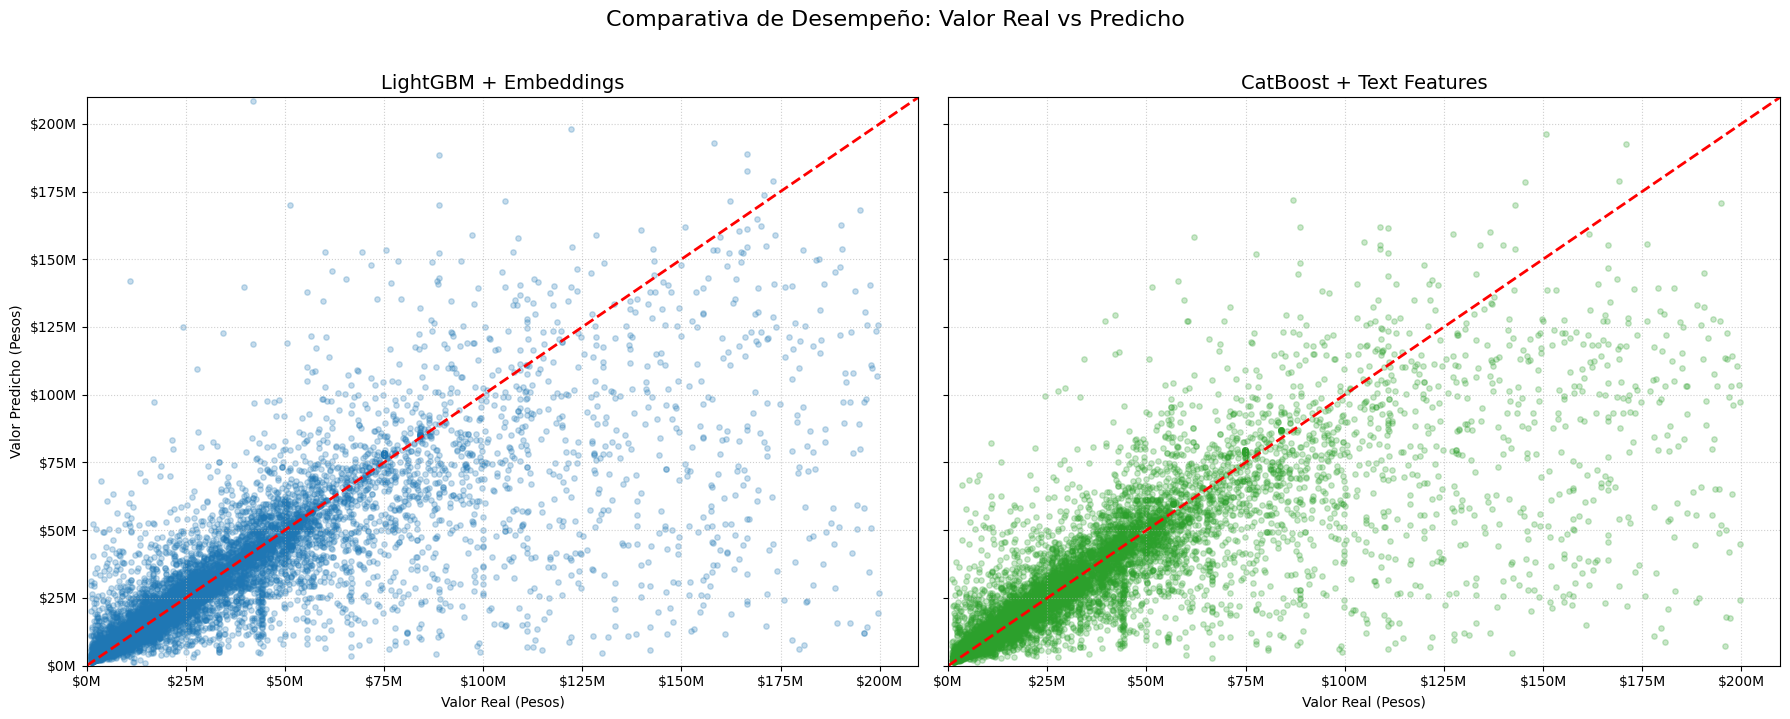

In [47]:
from evaluar_model import comparar_modelos3
comparar_modelos3(y_test_log, preds_lgbm_log, preds_cat_log)

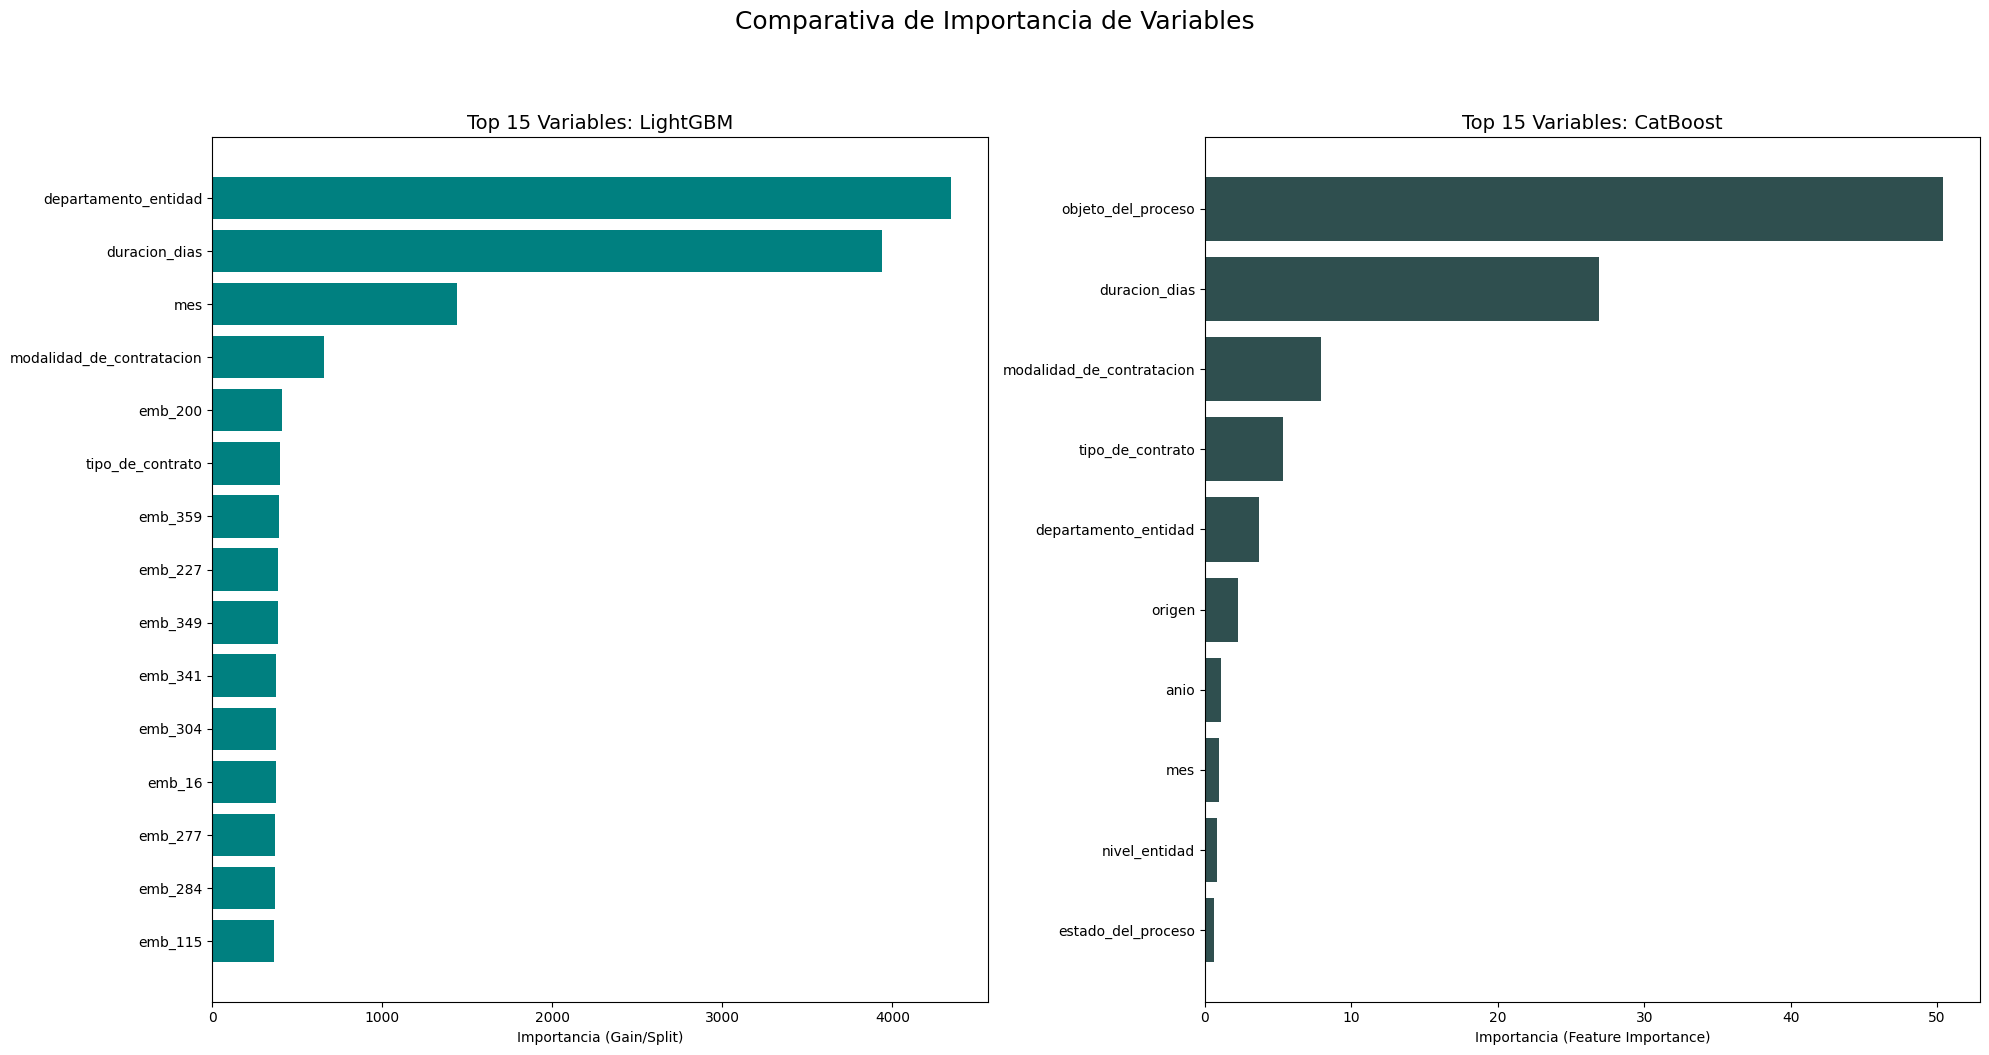

In [48]:
from evaluar_model import comparar_importancia
comparar_importancia(
    lgbm_model, 
    cat_model, 
    X_train_lgbm.columns, 
    X_train_cat.columns
)

## **Reporte de Evaluación:** <br>
Tras una evaluación bajo condiciones idénticas de entrenamiento y prueba, los resultados presentados confirman que CatBoost es la arquitectura más eficiente para la estimación de costos en la contratación estatal.<br>

Cuadro Comparativo de Desempeño


|**Metrica**|**LightGBM (Embeddings)**|**CatBoost (Texto Nativo)**|**Impacto**|
|-|-|-|-|
|$R^2$  |0.8156|0.8301|Explica el % de la variabilidad de precios.|
|MAE	|$8,440,523	|$8,428,888 |Error promedio por contrato en pesos.|
|RMSE	|$20,028,974|$19,431,686|Penaliza errores en contratos grandes.|

**Interpretación de Métricas Aplicadas**
Para entender estas cifras en el contexto del presupuesto público colombiano, debemos considerar:

MAE: Representa el margen de error promedio. En un contrato de obra de $200 M, este error puede ser aceptable. Sin embargo, en contratos de mínima cuantía ($10M - $20M), un error de este tamaño sugiere que el modelo debe ser usado con supervisión humana, ya que el error iguala a la mitad del valor real.

RMSE: Al ser mayor que el MAE, indica que existen contratos "atípicos" donde el modelo falla por montos altos. No obstante, CatBoost logra el RMSE más bajo, demostrando ser el más robusto para manejar contratos de alta cuantía sin desviaciones extremas.

R²: Es un indicador de confianza alto. Valida que variables como el objeto del proceso, departamento y modalidad son predictores sólidos del costo final.

**Modelo Seleccionado: CatBoost**

CatBoost superó a LightGBM en todas las métricas de precisión y estabilidad. Su capacidad para procesar el lenguaje técnico de los objetos contractuales de forma nativa resultó ser superior a la estrategia de embeddings externos.



## **Validación Cruzada: El Método K-Fold**

Se implementa una Validación Cruzada de 5 pliegues (5-Fold CV) sobre el modelo CatBoost seleccionado. Este procedimiento garantiza que la precisión del 83% reportada no sea un caso aislado, sino una métrica estadísticamente sólida que refleja la verdadera capacidad del algoritmo para estimar costos de contratación estatal en condiciones reales. Estas corridas se hacen el colab para aprovechar la GPU T4 y disminuir el tiempo de procesamiento en CPU.

Repositorio de colab para realizar K-Fold (validadcion cruzada):

https://colab.research.google.com/drive/1GGWC2LToeRZh2dFXQFEMh0XJ4etghsA9?usp=sharing

In [43]:
# Guardar los DataFrames preparados
X_cat.to_csv('data/X_cat_final.csv', index=False)
y_log.to_csv('data/y_log_final.csv', index=False)


Cargar metricas del K-FOLD

In [51]:
import os

#llamamos nuestro archivo bajado desde colab
ruta_metricas = os.path.join('data/metricas_kfold_final.csv')

# Cargamos el archivo
df_metricas = pd.read_csv(ruta_metricas)

# Visualizamos las primeras filas para confirmar
print("Métricas de KFOLD Cargadas con éxito:")


Métricas de KFOLD Cargadas con éxito:


In [52]:
# Visualizamos primeras filas
print("Métricas de KFOLD cargadas con éxito:")
print(df_metricas.head())

# Obtener la fila con el mejor RMSE
mejor_paso = df_metricas.loc[
    df_metricas['test-RMSE-mean'].idxmin()
]

# Resumen
print(f"\n--- Resumen para el Proyecto ---")
print(f"Iteración óptima: {int(mejor_paso['iterations'])}")
print(f"RMSE Final (Promedio): {mejor_paso['test-RMSE-mean']:.4f}")
print(f"Desviación Estándar (Estabilidad): {mejor_paso['test-RMSE-std']:.4f}")

Métricas de KFOLD cargadas con éxito:
   iterations  test-RMSE-mean  test-RMSE-std  train-RMSE-mean  train-RMSE-std
0           0       15.878568       0.007547        15.878566        0.001824
1           1       15.087117       0.007703        15.087120        0.001712
2           2       14.335754       0.007850        14.335745        0.001620
3           3       13.621761       0.007962        13.621738        0.001600
4           4       12.944532       0.007917        12.944412        0.001715

--- Resumen para el Proyecto ---
Iteración óptima: 7338
RMSE Final (Promedio): 0.4603
Desviación Estándar (Estabilidad): 0.0063


Se validó un modelo predictivo basado en el algoritmo CatBoost utilizando K-Fold Cross-Validation ($K=5$) en colab, obteniendo un error RMSE promedio de 0.4603 en escala logarítmica, el modelo es altamente consistente, ya que la variación del error entre los diferentes K-FOLDS de prueba es de apenas un 0.6% respecto al error promedio, La implementación de early stopping aseguró la estabilidad del modelo, logrando una alta capacidad de generalización para la estimación de presupuestos en procesos de contratación del SECOP II.


Se obtuvo el mejroo modelo despues del K-FOLD, arrojando las siguientes metricas de desempeño:

In [ ]:
# Leer el contenido del reporte Modelo final 
with open('data/reporte_final_metricas.txt', 'r') as f:
    print(f.read())

Reporte de Metricas Finales - SECOP II
R2: 0.9355848360775171
RMSE_log: 0.26671024380278774
MAE_cop: 6024153.275761933
MAPE: 19.38148131312886%


## **Conclusiones**

Al interpretar las métricas obtenidas (MAE de $6M y MAPE de 19.38%), es vital entender que el modelo no se equivoca de la misma forma en todos los rangos de presupuesto:<br>

En Contratos de Bajo Monto (Ej: $1,000,000 COP) <br>
El impacto del MAPE: si el modelo tiene un error porcentual del 19%, la predicción podría ser de $1,190,000 o $810,000. El error en pesos es pequeño ($190,000), lo cual es muy aceptable.

El riesgo del MAE: Aquí es donde el MAE ($6,024,153)<br>
puede ser engañoso. Si evaluamos un contrato de solo 1 millón usando el promedio de error global (6 millones), parecería que el modelo no sirve. Sin embargo, gracias a la escala logarítmica, el modelo entiende proporciones, no solo sumas fijas, permitiendo que en contratos pequeños el error también se mantenga proporcionalmente pequeño.

En Contratos de Alto Monto (Ej: $200,000,000 COP)<br>
El impacto del MAE: En este escenario, un error de $6,024,153 es excelente, ya que representa apenas el 3% del valor total del contrato.

El impacto del MAPE: El modelo se permite un margen de maniobra de hasta $38 millones (19.38%). En contratos grandes, las variables como "objeto del proceso" o "departamento" tienen más ruido, por lo que el modelo tiende a ser más conservador.

## **Análisis de Interpretabilidad del Modelo mediante SHAP**

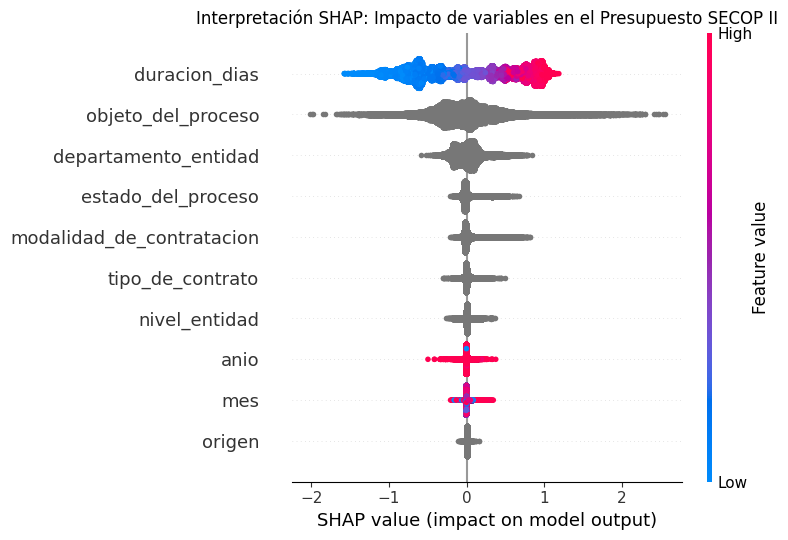

In [ ]:
# 1. Cargar el modelo .cbm
model = catboost.CatBoostRegressor()
model.load_model('data/modelo_final_secop.cbm') 

# 2. Cargar  datos (X) 
X = pd.read_csv('data/X_cat_final.csv') 

# 3. Calcular SHAP values usando la integración nativa de CatBoost
# Esto es mucho más rápido que el SHAP genérico
shap_values = model.get_feature_importance(
    catboost.Pool(X, cat_features=[
        'departamento_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
        'tipo_de_contrato', 'origen', 'anio', 'mes', 'nivel_entidad'
    ], text_features=['objeto_del_proceso']), 
    type='ShapValues'
)

# Los SHAP values de CatBoost incluyen el "expected value" en la última columna
# Separamos los valores de las características (todas menos la última)
expected_value = shap_values[0, -1]
shap_values_features = shap_values[:, :-1]

# 4. Graficar el Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_features, X, plot_type="dot", show=False)
plt.title("Interpretación SHAP: Impacto de variables en el Presupuesto SECOP II")
plt.tight_layout()
plt.savefig('data/shap_summary_secop.png')
plt.show()

El análisis SHAP evidenció que la variable con mayor impacto en las predicciones del modelo fue la duración del contrato (`duracion_dias`), mostrando una relación positiva entre contratos de mayor duración y presupuestos más elevados. Asimismo, la variable textual `objeto_del_proceso` presentó una alta capacidad explicativa, indicando que el modelo logró capturar relaciones semánticas relevantes entre el contenido descriptivo del contrato y su valor económico.

Variables como `departamento_entidad`, `estado_del_proceso` y `modalidad_de_contratacion` también contribuyeron al desempeño predictivo, aunque con menor intensidad. Por otro lado, variables temporales como `anio` y `mes` mostraron un impacto reducido sobre la predicción final, sugiriendo baja dependencia temporal en el comportamiento del presupuesto contractual.
